# Results for Diversity Experiments
(Lots of this code was taken from coqstoq-analysis.ipynb. Moved it here for organization.)

## Imports

In [1]:
import os
from typing import Optional
from pathlib import Path 
import json
from dataclasses import dataclass

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import scienceplots
# plt.style.use(['science', 'ieee', 'no-latex'])
# plt.rc("legend", fontsize="small")
# plt.rc("pdf", fonttype=42)


from coqstoq import get_theorem_list, Split
from coqstoq.check import Result

In [2]:
if Path(os.curdir).resolve().name == "evaluation":
    os.chdir("../..")
elif Path(os.curdir).resolve().name == "coq-modeling":
    pass
else:
    raise ValueError(f"In an unexpected directory: {os.curdir}")

## Helper Functions and Data Structures

In [3]:
@dataclass
class NamedDF:
    name: str
    df: pd.DataFrame


def create_skeleton_results(coqstoq_indices: set[int], coqstoq_loc: Path, split: str) -> NamedDF:
    thms = get_theorem_list(split, coqstoq_loc)
    rows = []
    for i, thm in enumerate(thms):
        if i not in coqstoq_indices:
            continue
        rows.append({
            "project": thm.project.workspace.name,
            "path": thm.path,
            "line": thm.theorem_start_pos.line,
            "success": False,
            "time": None,
        })
    df = pd.DataFrame(rows)
    return NamedDF(f"Skeleton {split}", df.set_index(["project", "path", "line"]))


def load_results(p: Path, sysname: str, timeout: int = 600) -> NamedDF:
    rows = [] 
    for r_path in p.glob("**/*.json"):
        with r_path.open() as f:
            r_data = json.load(f)
            result = Result.from_json(r_data)
            rows.append({
                "project": result.thm.project.workspace.name, 
                "path": result.thm.path,
                "line": result.thm.theorem_start_pos.line,
                "success": result.proof is not None and result.time is not None and result.time < timeout,
                "time": result.time,
            })
    df = pd.DataFrame(rows)
    return NamedDF(sysname, df.set_index(["project", "path", "line"]))

def create_joint_eval(df1: NamedDF, df2: NamedDF, normalize: bool=True, timeout: int=600) -> NamedDF:
    if normalize:
        new_name = f"Adjusted {df1.name} + {df2.name}"
    else:
        new_name = f"Unadjusted {df1.name} + {df2.name}"
    merged_df = df1.df.merge(df2.df, left_index=True, right_index=True, how="outer", suffixes=("_1", "_2"))
    if normalize:
        merged_df["time"] = merged_df.apply(lambda row: min(row["time_1"], row["time_2"]) * 2, axis=1)
    else:
        merged_df["time"] = merged_df.apply(lambda row: min(row["time_1"], row["time_2"]), axis=1)
    merged_df["success"] = (merged_df["success_1"] | merged_df["success_2"]) & (merged_df["time"] < timeout)
    return NamedDF(new_name, merged_df[["success", "time"]])


def filter_df(named_df: NamedDF, idx : pd.Index) -> NamedDF:
    return NamedDF(named_df.name, named_df.df.loc[idx])


def mk_time_plot(ndfs: list[NamedDF], timeout: int = 600, save_path: Optional[Path] = None): 
    fig, ax = plt.subplots()
    assert 0 < len(ndfs)
    num_thms = len(ndfs[0].df)
    for ndf in ndfs:
        cur_num_thms = len(ndf.df)
        assert cur_num_thms == num_thms
        success_df = ndf.df.loc[ndf.df["success"]]
        by_time = list(success_df.sort_values("time")["time"]) + [timeout]
        successes = list(np.arange(len(success_df)) + 1) + [len(success_df)]
        ax.plot(by_time, successes, label=ndf.name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("# Theorems Proven")
    ax.set_title(f"# Theorems Proven out of {num_thms}")
    ax.legend()
    if save_path is not None:
        plt.savefig(save_path)
    

def get_by_project_summary(named_df: NamedDF) -> pd.DataFrame:
    return named_df.df.groupby("project").agg(
        RATE=("success", "mean"), 
        SUCCESSES=("success", "sum"), 
        TOTAL=("success", "count")
    ).sort_values("TOTAL", ascending=False)


def get_totals(named_df: NamedDF) -> pd.Series:
    n_df = NamedDF(named_df.name, named_df.df.agg(
        RATE=("success", "mean"), 
        SUCCESSES=("success", "sum"), 
        TOTAL=("success", "count")
    ))
    series = n_df.df["success"]
    series.name = named_df.name
    return series

## Rango No Lemmas <+> Rango No Proofs

### TODO:
- Generate any "incomplete results"
- Run w/o Lemmas only  -- Running
- Run w/o Proofs only  -- Running
- Run (w/o Lemmas) + (w/o Proofs)

In [4]:
SKELETON_RESULTS = create_skeleton_results(set(range(450)), Path("CoqStoq"), "test")

In [ ]:
DIV_SEARCH = load_results(Path("evaluations/coqstoq-results/test-diversity-0"), "Prefix + Rango (Diversity)")
PROOFS = load_results(Path("evaluations/coqstoq-results/test-diversity-proof-long-seq"), "Rango w/ Proofs Only")
LEMMAS = load_results(Path("evaluations/coqstoq-results/test-diversity-lemma-long-seq"), "Rango w/ Lemmas Only")

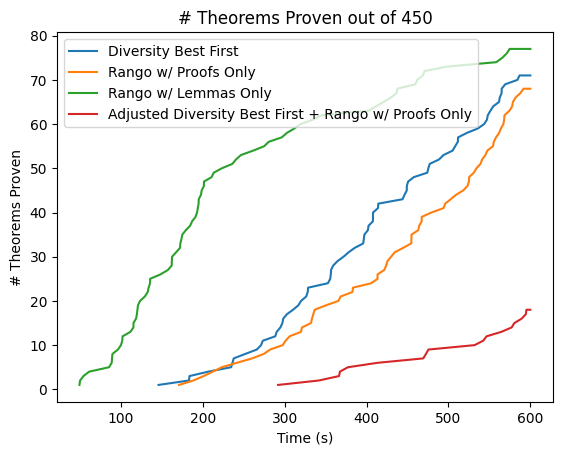

In [ ]:
div_filtered = filter_df(DIV_SEARCH, SKELETON_RESULTS.df.index)
proofs_filtered = filter_df(PROOFS, SKELETON_RESULTS.df.index)
lemmas_filtered = filter_df(LEMMAS, SKELETON_RESULTS.df.index)
# naive = create_joint_eval(div_filtered, proofs_filtered, normalize=False)
naive_norm = create_joint_eval(div_filtered, proofs_filtered, normalize=True)
mk_time_plot([div_filtered, proofs_filtered, lemmas_filtered, naive_norm], timeout=3600, save_path=Path("evaluations/coqstoq-results/test-diversity.pdf"))

In [17]:
pd.concat([
    get_totals(div_filtered),
])

RATE            0.284
SUCCESSES     284.000
TOTAL        1000.000
Name: Diversity Best First, dtype: float64

## Rango <+> Rango-PRE

## TODO:
- Generate any missing results

In [4]:
SKELETON_RESULTS = create_skeleton_results(set(range(1000)), Path("CoqStoq"), "test")

In [5]:
DEPTH_FIRST = load_results(Path("evaluations/coqstoq-results/test-diversity-depth"), "Diversity Depth First")
DIV_SEARCH = load_results(Path("evaluations/coqstoq-results/test-diversity-0"), "Diversity Best First")
RANGO_SEARCH = load_results(Path("evaluations/coqstoq-results/test-diversity-rango"), "Rango Best First")
PREFIX_SEARCH = load_results(Path("evaluations/coqstoq-results/test-diversity-prefix"), "Prefix Best First")

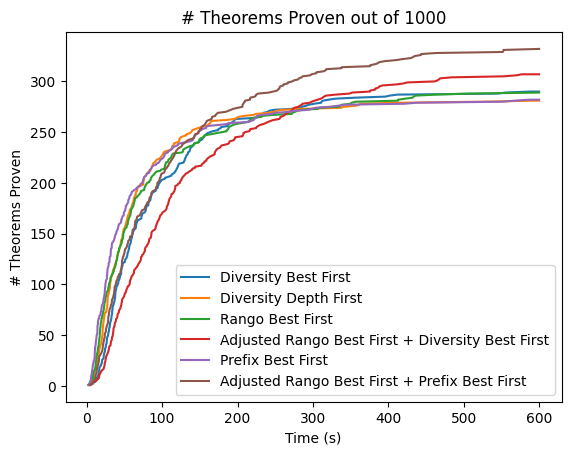

In [ ]:
div_filtered = filter_df(DIV_SEARCH, SKELETON_RESULTS.df.index)
div_depth_filtered = filter_df(DEPTH_FIRST, SKELETON_RESULTS.df.index)
rango_filtered = filter_df(RANGO_SEARCH, SKELETON_RESULTS.df.index)
prefix_filtered = filter_df(PREFIX_SEARCH, SKELETON_RESULTS.df.index)
rango_prefix = create_joint_eval(rango_filtered, prefix_filtered, normalize=True)
rango_div = create_joint_eval(rango_filtered, div_filtered, normalize=True)
mk_time_plot([div_filtered, rango_div, div_depth_filtered, rango_filtered, prefix_filtered, rango_prefix])

In [14]:
pd.concat([
  get_totals(div_filtered),
  get_totals(div_depth_filtered),
  get_totals(rango_filtered),
  get_totals(prefix_filtered),
  get_totals(rango_prefix),
], axis=1)

,Diversity Best First,Diversity Depth First,Rango Best First,Prefix Best First,Adjusted Rango Best First + Prefix Best First
RATE,0.284,0.281,0.289,0.282,0.332
SUCCESSES,284.000,281.000,289.000,282.000,332.000
TOTAL,1000.000,1000.000,1000.000,1000.000,1000.000
